In [1]:
# Bibliotecas básicas
import numpy as np
import gmsh
import pyvista

from mpi4py import MPI
from petsc4py import PETSc

# DOLFINx / FEniCSx
from dolfinx import fem, default_scalar_type
from dolfinx.io import gmshio
from dolfinx.plot import vtk_mesh
from dolfinx.fem import (
    functionspace, Function, Constant, dirichletbc,
    locate_dofs_geometrical, locate_dofs_topological, Expression
)
from dolfinx.fem.petsc import LinearProblem

# UFL
from ufl import (
    SpatialCoordinate, TrialFunction, TestFunction,
    dot, grad, dx, as_vector
)

In [2]:
# Constantes físicas
eps0 = 8.854187817e-12  # permissividade do vácuo [F/m]

# Dados do TC04
gamma = 0.05            # tensão superficial da formamida [N/m]
epsr = 84.0             # permissividade relativa da formamida

R = 0.12e-3 / 2         # raio do tubo capilar [m]
d = 6e-3                # distância entre tubo e eletrodo [m]
Ra = 2e-3               # raio interno do eletrodo [m]
Rb = 9e-3               # raio externo do eletrodo [m]
Rc = R                  # raio de curvatura do líquido [m]

# Campo crítico analítico
Ecrit = np.sqrt(np.pi * gamma / (2 * eps0 * R))

# Tensão analítica aproximada
V_analytic = np.sqrt(gamma * Rc / eps0) * np.log(4 * d / Rc)

print(f"R = {R:.3e} m")
print(f"Ecrit = {Ecrit:.6e} V/m")
print(f"V_analytic = {V_analytic:.3f} V")

R = 6.000e-05 m
Ecrit = 1.215892e+07 V/m
V_analytic = 3487.540 V


In [3]:
# Geometria usando OCC: ar - eletrodo - emissor com topo circular

if gmsh.isInitialized():
    gmsh.finalize()

gmsh.initialize()
gmsh.model.add("TC04_occ")

gdim = 2
model_rank = 0
mesh_comm = MPI.COMM_WORLD

if mesh_comm.rank == model_rank:

    occ = gmsh.model.occ

    # Dimensões do domínio
    rmax = 12e-3
    zmax = 12e-3

    # Geometria do emissor
    z_nozzle = 3e-3

    # Geometria do eletrodo
    z_electrode = z_nozzle + d
    t_electrode = 2 * R

    # Tamanhos de malha
    lc_far = 0.35e-3
    lc_near = R / 4

    # -------------------------
    # Região externa de ar
    # -------------------------
    air = occ.addRectangle(
        0.0, 0.0, 0.0,
        rmax, zmax
    )

    # -------------------------
    # Eletrodo como retângulo
    # -------------------------
    barrier = occ.addRectangle(
        Ra, z_electrode, 0.0,
        Rb - Ra, t_electrode
    )

    # -------------------------
    # Emissor: retângulo + círculo
    # -------------------------
    nozzle_rect = occ.addRectangle(
        0.0, 0.0, 0.0,
        R, z_nozzle
    )

    circle = occ.addDisk(
        0.0, z_nozzle, 0.0,
        R, R
    )

    # Junta retângulo e círculo para formar o emissor arredondado
    nozzle_join, _ = occ.fuse(
        [(2, nozzle_rect)],
        [(2, circle)]
    )

    occ.synchronize()

    # -------------------------
    # Retira emissor e eletrodo do domínio do ar
    # -------------------------
    holes = [(2, barrier)] + nozzle_join

    domain, _ = occ.cut(
        [(2, air)],
        holes,
        removeObject=True,
        removeTool=True
    )

    occ.synchronize()

    # Pega as superfícies restantes do domínio de ar
    air_surfaces = [tag for dim, tag in domain if dim == 2]

    AIR = 1

    gmsh.model.addPhysicalGroup(2, air_surfaces, AIR)
    gmsh.model.setPhysicalName(2, AIR, "air")

    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", lc_far)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", lc_near)

    gmsh.model.mesh.generate(gdim)

mesh, cell_tags, facet_tags = gmshio.model_to_mesh(
    gmsh.model,
    mesh_comm,
    model_rank,
    gdim=gdim
)

gmsh.finalize()

Info    : Cannot bind existing OpenCASCADE surface 3 to second tag 4                                                               
Info    : Could not preserve tag of 2D object 4 (->3)
Info    : Meshing 1D...                                                                                                                 
Info    : [  0%] Meshing curve 5 (Line)
Info    : [ 20%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Ellipse)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 90%] Meshing curve 15 (Line)
Info    : [100%] Meshing curve 16 (Line)
Info    : Done meshing 1D (Wall 0.00181974s, CPU 0.00203s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0508383s, CPU 0.051139s)
Info    : 1718 nodes 3446 elements


In [4]:
V = functionspace(mesh, ("Lagrange", 2))

Vc = 1.0
tol = 1e-8

z_nozzle = 3e-3
z_electrode = z_nozzle + d
t_electrode = 2 * R

def boundary_nozzle(x):
    # Parede lateral reta do emissor
    wall = np.logical_and(
        np.isclose(x[0], R, atol=tol),
        np.logical_and(x[1] >= -tol, x[1] <= z_nozzle + tol)
    )

    # Arco circular do topo
    dist = np.sqrt(x[0]**2 + (x[1] - z_nozzle)**2)

    arc = np.logical_and(
        np.isclose(dist, R, atol=tol),
        np.logical_and(
            x[0] >= -tol,
            np.logical_and(x[0] <= R + tol, x[1] >= z_nozzle - tol)
        )
    )

    return np.logical_or(wall, arc)


def boundary_barrier(x):
    # Eletrodo retangular: todos os lados expostos do condutor
    between_x = np.logical_and(x[0] >= Ra - tol, x[0] <= Rb + tol)
    between_z = np.logical_and(x[1] >= z_electrode - tol, x[1] <= z_electrode + t_electrode + tol)

    bottom = np.logical_and(np.isclose(x[1], z_electrode, atol=tol), between_x)
    top = np.logical_and(np.isclose(x[1], z_electrode + t_electrode, atol=tol), between_x)
    left = np.logical_and(np.isclose(x[0], Ra, atol=tol), between_z)
    right = np.logical_and(np.isclose(x[0], Rb, atol=tol), between_z)

    return np.logical_or(np.logical_or(bottom, top), np.logical_or(left, right))


dofs_nozzle = locate_dofs_geometrical(V, boundary_nozzle)
dofs_barrier = locate_dofs_geometrical(V, boundary_barrier)

print("dofs_nozzle:", len(dofs_nozzle))
print("dofs_barrier:", len(dofs_barrier))

bc_nozzle = dirichletbc(PETSc.ScalarType(+Vc / 2), dofs_nozzle, V)
bc_barrier = dirichletbc(PETSc.ScalarType(-Vc / 2), dofs_barrier, V)

bcs = [bc_nozzle, bc_barrier]

dofs_nozzle: 21
dofs_barrier: 84


In [5]:
# Coordenada radial
x = SpatialCoordinate(mesh)
rho = x[0]

# Funções trial e teste
u = TrialFunction(V)
v = TestFunction(V)

# Permissividade absoluta
eps = Constant(mesh, PETSc.ScalarType(eps0 * epsr))

# Forma fraca axissimétrica
a = eps * rho * dot(grad(u), grad(v)) * dx

# Lado direito nulo
zero = Constant(mesh, PETSc.ScalarType(0.0))
L = zero * v * rho * dx

# Resolver
phi = Function(V)
problem = LinearProblem(a, L, u=phi, bcs=bcs)
problem.solve()

Coefficient(FunctionSpace(Mesh(blocked element (Basix element (P, triangle, 1, equispaced, unset, False, float64, []), (2,)), 0), Basix element (P, triangle, 2, gll_warped, unset, False, float64, [])), 0)

In [6]:
# Campo elétrico E = -grad(phi)
W = functionspace(mesh, ("DG", 0, (mesh.geometry.dim,)))

E = Function(W)
E_expr = Expression(
    as_vector((-phi.dx(0), -phi.dx(1))),
    W.element.interpolation_points()
)

E.interpolate(E_expr)

error: XDG_RUNTIME_DIR is invalid or not set in the environment.
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


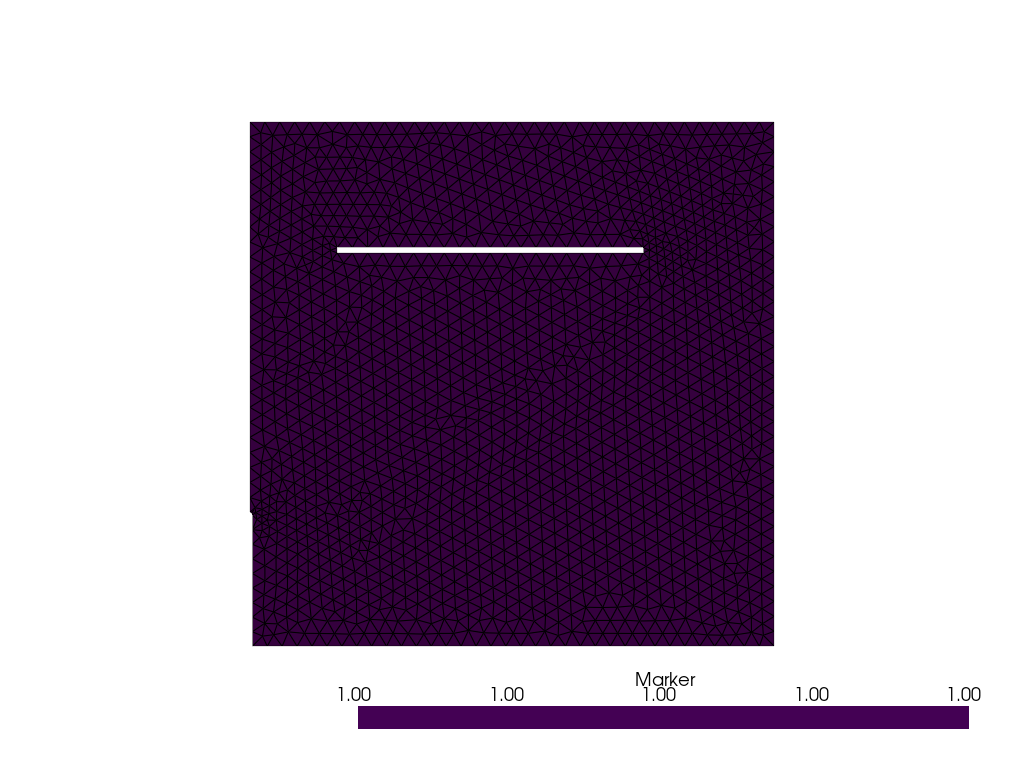

In [7]:
pyvista.start_xvfb()

plotter = pyvista.Plotter()

gdim = mesh.topology.dim

mesh.topology.create_connectivity(gdim, gdim)

grid = pyvista.UnstructuredGrid(*vtk_mesh(mesh, gdim))

num_local_cells = mesh.topology.index_map(gdim).size_local

cell_values = np.zeros(num_local_cells, dtype=np.int32)

if len(cell_tags.indices) > 0:
    mask = cell_tags.indices < num_local_cells
    cell_values[cell_tags.indices[mask]] = cell_tags.values[mask]

grid.cell_data["Marker"] = cell_values
grid.set_active_scalars("Marker")

plotter.add_mesh(
    grid,
    show_edges=True,
    cmap="viridis",
    edge_color="black"
)

plotter.view_xy()
plotter.show()

Facetas do emissor: 11
Facetas do eletrodo: 42


error: XDG_RUNTIME_DIR is invalid or not set in the environment.
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


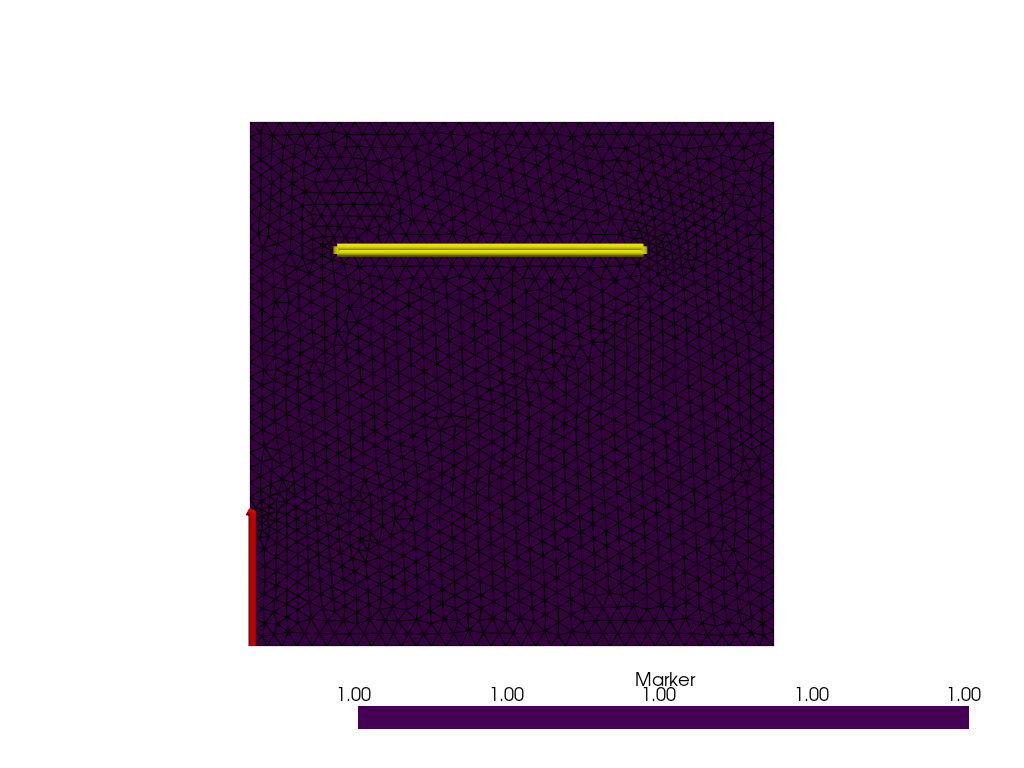

In [13]:
import numpy as np
import pyvista
from dolfinx.plot import vtk_mesh
from dolfinx.mesh import locate_entities_boundary

pyvista.start_xvfb()

plotter = pyvista.Plotter()

gdim = mesh.topology.dim
fdim = gdim - 1

mesh.topology.create_connectivity(gdim, gdim)

grid = pyvista.UnstructuredGrid(*vtk_mesh(mesh, gdim))

num_local_cells = mesh.topology.index_map(gdim).size_local

cell_values = np.zeros(num_local_cells, dtype=np.int32)

if len(cell_tags.indices) > 0:
    mask = cell_tags.indices < num_local_cells
    cell_values[cell_tags.indices[mask]] = cell_tags.values[mask]

grid.cell_data["Marker"] = cell_values
grid.set_active_scalars("Marker")

# -------------------------
# AQUI fica EXATAMENTE seu plot original
# -------------------------
plotter.add_mesh(
    grid,
    show_edges=True,
    cmap="viridis",
    edge_color="black"
)

# -------------------------
# Só acrescentamos isso abaixo
# -------------------------

tol = 1e-8
z_nozzle = 3e-3
z_electrode = z_nozzle + d
t_electrode = 2 * R

# emissor
def emitter_marker(x):
    wall = np.logical_and(
        np.isclose(x[0], R, atol=tol),
        np.logical_and(x[1] >= -tol, x[1] <= z_nozzle + tol)
    )

    dist = np.sqrt(x[0]**2 + (x[1] - z_nozzle)**2)
    arc = np.logical_and(
        np.isclose(dist, R, atol=5*tol),
        np.logical_and(
            x[0] >= -tol,
            np.logical_and(x[0] <= R + tol, x[1] >= z_nozzle - tol)
        )
    )

    return np.logical_or(wall, arc)

# eletrodo
def electrode_marker(x):
    between_x = np.logical_and(x[0] >= Ra - tol, x[0] <= Rb + tol)
    between_z = np.logical_and(
        x[1] >= z_electrode - tol,
        x[1] <= z_electrode + t_electrode + tol
    )

    bottom = np.logical_and(np.isclose(x[1], z_electrode, atol=tol), between_x)
    top    = np.logical_and(np.isclose(x[1], z_electrode + t_electrode, atol=tol), between_x)
    left   = np.logical_and(np.isclose(x[0], Ra, atol=tol), between_z)
    right  = np.logical_and(np.isclose(x[0], Rb, atol=tol), between_z)

    return np.logical_or(np.logical_or(bottom, top), np.logical_or(left, right))

# encontra as facetas
emitter_facets = locate_entities_boundary(mesh, fdim, emitter_marker)
electrode_facets = locate_entities_boundary(mesh, fdim, electrode_marker)

print("Facetas do emissor:", len(emitter_facets))
print("Facetas do eletrodo:", len(electrode_facets))

# desenha emissor por cima
if len(emitter_facets) > 0:
    etop, etypes, egeom = vtk_mesh(mesh, fdim, emitter_facets)
    emitter_grid = pyvista.UnstructuredGrid(etop, etypes, egeom)
    plotter.add_mesh(
        emitter_grid,
        color="red",
        line_width=8,
        render_lines_as_tubes=True
    )

# desenha eletrodo por cima
if len(electrode_facets) > 0:
    ttop, ttypes, tgeom = vtk_mesh(mesh, fdim, electrode_facets)
    electrode_grid = pyvista.UnstructuredGrid(ttop, ttypes, tgeom)
    plotter.add_mesh(
        electrode_grid,
        color="yellow",
        line_width=8,
        render_lines_as_tubes=True
    )

plotter.view_xy()
plotter.show()